Merged shape: (590540, 434)
After cleaning: (590540, 112)
Features: (590540, 111) | Fraud rate: 0.035

=== Baseline (threshold=0.5) ===
              precision    recall  f1-score   support

           0     0.9860    0.9666    0.9762    113975
           1     0.4029    0.6209    0.4887      4133

    accuracy                         0.9545    118108
   macro avg     0.6944    0.7937    0.7324    118108
weighted avg     0.9656    0.9545    0.9591    118108

Accuracy: 0.9545
ROC AUC: 0.9141


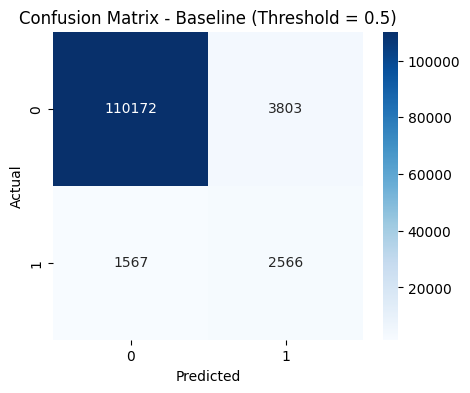


=== F1-Optimized Threshold ===
Chosen threshold: 0.6411 | Precision=0.5938 | Recall=0.4946 | F1=0.5397
              precision    recall  f1-score   support

           0     0.9818    0.9877    0.9847    113975
           1     0.5938    0.4946    0.5397      4133

    accuracy                         0.9705    118108
   macro avg     0.7878    0.7411    0.7622    118108
weighted avg     0.9682    0.9705    0.9692    118108

Accuracy: 0.9705
ROC AUC (unchanged): 0.9141


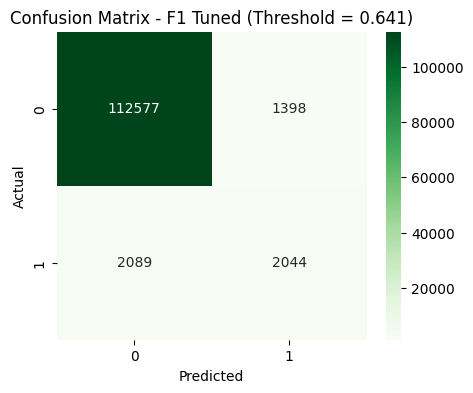


=== Target Recall (≥ 0.50) ===
Threshold: 0.6339 | Precision=0.5814 | Recall=0.5001
              precision    recall  f1-score   support

           0     0.9820    0.9869    0.9844    113975
           1     0.5814    0.5001    0.5377      4133

    accuracy                         0.9699    118108
   macro avg     0.7817    0.7435    0.7611    118108
weighted avg     0.9679    0.9699    0.9688    118108



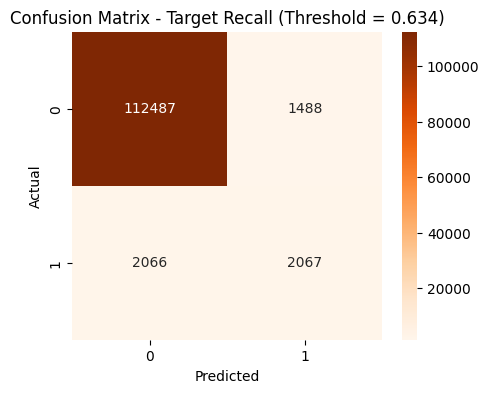

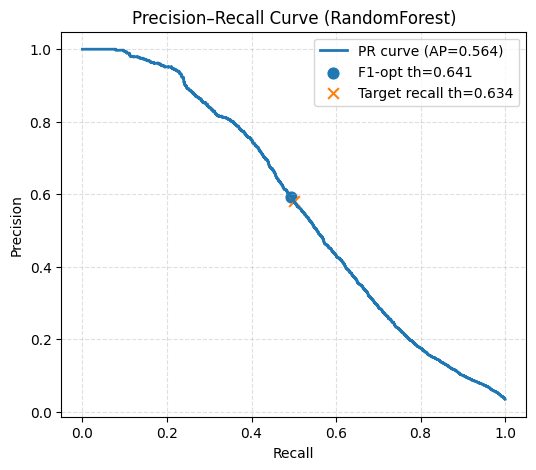

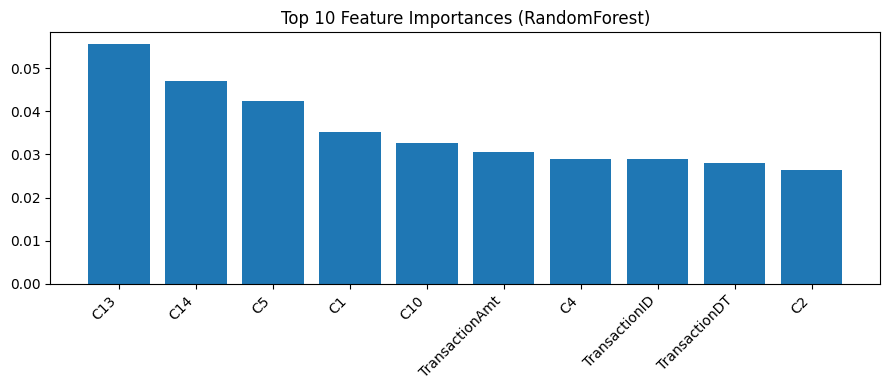


✅ Completed: Baseline, Tuned Thresholds, Confusion Matrices, PR Curve, Feature Importance.


In [ ]:
# === COLAB DEMO: Random Forest Fraud Detection + Threshold Tuning + Confusion Matrix Plots ===
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, warnings
warnings.filterwarnings('ignore')

# 0) Load or ask for upload
tx_path = "/content/train_transaction.csv"
id_path = "/content/train_identity.csv"

if not (os.path.exists(tx_path) and os.path.exists(id_path)):
    try:
        from google.colab import files
        print("Upload train_transaction.csv and train_identity.csv …")
        uploaded = files.upload()  # upload both files when prompted
    except Exception as e:
        raise RuntimeError("Please ensure train_transaction.csv and train_identity.csv are uploaded.") from e

# 1) Read & merge
transaction = pd.read_csv(tx_path)
identity    = pd.read_csv(id_path)
df = pd.merge(transaction, identity, on='TransactionID', how='left')
print("Merged shape:", df.shape)

# 2) Cleaning
threshold = 0.9 * len(df)
df = df.dropna(thresh=threshold, axis=1)

num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

cat_cols = df.select_dtypes(include='object').columns
for c in cat_cols:
    df[c] = df[c].fillna(df[c].mode()[0])

print("After cleaning:", df.shape)

# 3) Encode + scale
from sklearn.preprocessing import LabelEncoder, StandardScaler
le = LabelEncoder()
for c in cat_cols:
    df[c] = le.fit_transform(df[c].astype(str))

if 'isFraud' in num_cols:
    num_cols = num_cols.drop('isFraud')

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

# 4) Split features/target
df['isFraud'] = df['isFraud'].astype(int)
X = df.drop(columns=['isFraud'])
y = df['isFraud']

print("Features:", X.shape, "| Fraud rate:", round(y.mean(), 4))

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 5) Train Random Forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=18,
    class_weight='balanced_subsample',
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)

# 6) Predictions
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, accuracy_score,
    precision_recall_curve, average_precision_score
)
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

# 7) Baseline Metrics
print("\n=== Baseline (threshold=0.5) ===")
print(classification_report(y_test, y_pred, digits=4))
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("ROC AUC:", round(roc_auc_score(y_test, y_prob), 4))

cm_base = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Baseline (Threshold = 0.5)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 8) Threshold Tuning (F1-optimal)
prec, rec, th = precision_recall_curve(y_test, y_prob)
f1s = 2 * (prec[:-1]*rec[:-1]) / (prec[:-1]+rec[:-1]+1e-12)
best_idx = np.argmax(f1s)
best_th = th[best_idx]

y_pred_f1 = (y_prob >= best_th).astype(int)

print(f"\n=== F1-Optimized Threshold ===")
print(f"Chosen threshold: {best_th:.4f} | Precision={prec[best_idx]:.4f} | Recall={rec[best_idx]:.4f} | F1={f1s[best_idx]:.4f}")
print(classification_report(y_test, y_pred_f1, digits=4))
print("Accuracy:", round(accuracy_score(y_test, y_pred_f1), 4))
print("ROC AUC (unchanged):", round(roc_auc_score(y_test, y_prob), 4))

cm_f1 = confusion_matrix(y_test, y_pred_f1)
plt.figure(figsize=(5,4))
sns.heatmap(cm_f1, annot=True, fmt='d', cmap='Greens')
plt.title(f"Confusion Matrix - F1 Tuned (Threshold = {best_th:.3f})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 9) (Optional) Target Recall Tuning
target_recall = 0.50
idx = np.where(rec[:-1] >= target_recall)[0]
if len(idx) > 0:
    tr_idx = idx[-1]
    th_recall = th[tr_idx]
    y_pred_tar = (y_prob >= th_recall).astype(int)
    print(f"\n=== Target Recall (≥ {target_recall:.2f}) ===")
    print(f"Threshold: {th_recall:.4f} | Precision={prec[tr_idx]:.4f} | Recall={rec[tr_idx]:.4f}")
    print(classification_report(y_test, y_pred_tar, digits=4))
    cm_tar = confusion_matrix(y_test, y_pred_tar)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm_tar, annot=True, fmt='d', cmap='Oranges')
    plt.title(f"Confusion Matrix - Target Recall (Threshold = {th_recall:.3f})")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# 10) Precision–Recall Curve
ap = average_precision_score(y_test, y_prob)
plt.figure(figsize=(6,5))
plt.plot(rec, prec, linewidth=2, label=f'PR curve (AP={ap:.3f})')
plt.scatter(rec[best_idx], prec[best_idx], s=60, marker='o', label=f'F1-opt th={best_th:.3f}')
try:
    plt.scatter(rec[tr_idx], prec[tr_idx], s=60, marker='x', label=f'Target recall th={th_recall:.3f}')
except:
    pass
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve (RandomForest)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.show()

# 11) Feature Importances
importances = rf.feature_importances_
top_idx = np.argsort(importances)[-10:][::-1]
plt.figure(figsize=(9,4))
plt.title("Top 10 Feature Importances (RandomForest)")
plt.bar(range(len(top_idx)), importances[top_idx], align="center")
plt.xticks(range(len(top_idx)), [X.columns[i] for i in top_idx], rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n✅ Completed: Baseline, Tuned Thresholds, Confusion Matrices, PR Curve, Feature Importance.")


In [ ]:
# === SAVE MODEL, SCALER, AND THRESHOLD FOR LIVE DEMO ===
import joblib

# Save model, scaler, and best threshold
model_path = "/content/fraud_rf_model.pkl"
scaler_path = "/content/fraud_scaler.pkl"
th_path = "/content/fraud_threshold.txt"

joblib.dump(rf, model_path)
joblib.dump(scaler, scaler_path)

with open(th_path, "w") as f:
    f.write(str(best_th))

print(f"✅ Model saved to: {model_path}")
print(f"✅ Scaler saved to: {scaler_path}")
print(f"✅ Threshold saved: {best_th:.4f}")


✅ Model saved to: /content/fraud_rf_model.pkl
✅ Scaler saved to: /content/fraud_scaler.pkl
✅ Threshold saved: 0.6411


In [ ]:
# === LIVE PREDICTION FUNCTION ===
import numpy as np

# Reload everything (for safety)
rf_loaded = joblib.load(model_path)
scaler_loaded = joblib.load(scaler_path)

with open(th_path, "r") as f:
    tuned_th = float(f.read())

def predict_fraud(sample_dict):
    """
    sample_dict: dictionary of one transaction's features (only those present in model)
    Example:
    sample = {
        'TransactionAmt': 120.5,
        'card1': 1500,
        'C1': 0.3,
        'C13': 0.9,
        ...
    }
    """
    # Convert to dataframe
    sample_df = pd.DataFrame([sample_dict])

    # Match column order with training data
    sample_df = sample_df.reindex(columns=X.columns, fill_value=0)

    # Scale numeric columns
    sample_df[num_cols] = scaler_loaded.transform(sample_df[num_cols])

    # Predict fraud probability
    prob = rf_loaded.predict_proba(sample_df)[:, 1][0]
    label = int(prob >= tuned_th)

    print(f"Fraud Probability: {prob:.3f}")
    print(f"Predicted Label: {'FRAUD ⚠️' if label==1 else 'Legitimate ✅'}")
    return prob, label


In [ ]:
sample_transaction = {
    'TransactionAmt': 250.75,
    'card1': 1001,
    'C1': 0.45,
    'C13': 1.2,
    'TransactionDT': 0.56,
    'addr1': 300.0,
    'DeviceType': 1,
    'id_01': 0.22,
}

predict_fraud(sample_transaction)


In [ ]:
# === Interactive Fraud Predictor (ipywidgets) ===
import joblib, numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display, clear_output
import ipywidgets as widgets

# --- Load artifacts (safe if already loaded) ---
try:
    rf_loaded
    scaler_loaded
    tuned_th
except NameError:
    rf_loaded = joblib.load("/content/fraud_rf_model.pkl")
    scaler_loaded = joblib.load("/content/fraud_scaler.pkl")
    with open("/content/fraud_threshold.txt","r") as f:
        tuned_th = float(f.read())

# --- Pick a small set of user-friendly inputs (must exist in X.columns) ---
feature_defaults = {
    'TransactionAmt' : 100.0,
    'card1'          : 1500.0,
    'C1'             : 0.0,
    'C13'            : 0.0,
    'TransactionDT'  : 0.0,
    # add more if they exist in your X.columns (optional):
    # 'addr1'       : 300.0,
    # 'DeviceType'  : 1.0,    # ensure it’s encoded already
}

# Filter only features that actually exist in your trained X
feature_defaults = {k:v for k,v in feature_defaults.items() if k in X.columns}

# Build widgets
inputs = {k: widgets.FloatText(value=v, description=k, step=0.1, layout=widgets.Layout(width='300px'))
          for k,v in feature_defaults.items()}
predict_btn = widgets.Button(description='Predict Fraud', button_style='primary')
out = widgets.Output()

# UI layout
ui = widgets.VBox([
    widgets.HTML("<h3>Live Fraud Prediction</h3><p>Enter feature values and click Predict.</p>"),
    widgets.GridBox(list(inputs.values()), layout=widgets.Layout(grid_template_columns="repeat(2, 320px)", grid_gap="8px")),
    predict_btn,
    out
])

def _prepare_row():
    # Make a one-row dataframe in model column order
    sample = pd.DataFrame([ {k: w.value for k,w in inputs.items()} ])
    sample = sample.reindex(columns=X.columns, fill_value=0)
    # Scale numeric columns using the loaded scaler
    # Use intersection in case some numeric cols differ
    num_cols_in_use = [c for c in sample.columns if c in num_cols]
    sample[num_cols_in_use] = scaler_loaded.transform(sample[num_cols_in_use])
    return sample

def on_predict_clicked(b):
    with out:
        clear_output()
        sample = _prepare_row()
        prob = float(rf_loaded.predict_proba(sample)[:,1][0])
        label = int(prob >= tuned_th)
        print(f"Fraud Probability: {prob:.3f}")
        print(f"Predicted Label: {'FRAUD ⚠️' if label==1 else 'Legitimate ✅'}")

        # Simple probability bar
        plt.figure(figsize=(4, 1.0))
        plt.barh([0], [prob])
        plt.xlim(0,1)
        plt.yticks([])
        plt.xlabel("Probability of Fraud")
        plt.title("Prediction")
        plt.show()

predict_btn.on_click(on_predict_clicked)
display(ui)


In [ ]:
# === Interactive Fraud Predictor with Preset Examples (ipywidgets) ===
import joblib, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from IPython.display import display, clear_output
import ipywidgets as widgets

# --- Load artifacts if not already in memory ---
try:
    rf_loaded
    scaler_loaded
    tuned_th
except NameError:
    rf_loaded = joblib.load("/content/fraud_rf_model.pkl")
    scaler_loaded = joblib.load("/content/fraud_scaler.pkl")
    with open("/content/fraud_threshold.txt","r") as f:
        tuned_th = float(f.read())

# --- Minimal, user-friendly feature set (only include if present in your model columns) ---
feature_defaults = {
    'TransactionAmt' : 100.0,
    'card1'          : 1500.0,
    'C1'             : 0.2,
    'C13'            : 0.2,
    'TransactionDT'  : 0.40,
}
feature_defaults = {k:v for k,v in feature_defaults.items() if k in X.columns}

# --- Preset examples (edit values if your model reacts differently) ---
presets_all = {
    "Legitimate (small, regular time, stable behavior)" : {
        'TransactionAmt': 45.60, 'card1': 1500, 'C1': 0.25, 'C13': 0.15, 'TransactionDT': 0.40
    },
    "Fraudulent (large amount, odd time, spiky behavior)" : {
        'TransactionAmt': 95000.0, 'card1': 1020, 'C1': 4.2, 'C13': 3.8, 'TransactionDT': 0.95
    },
    "Borderline (mid amount, slightly irregular)" : {
        'TransactionAmt': 340.0, 'card1': 1600, 'C1': 1.4, 'C13': 0.9, 'TransactionDT': 0.78
    }
}
# Keep only keys that exist in your trained X
presets = {name: {k:v for k,v in d.items() if k in X.columns} for name,d in presets_all.items()}

# --- Widgets ---
inputs = {k: widgets.FloatText(value=v, description=k, step=0.1,
                               layout=widgets.Layout(width='300px')) for k,v in feature_defaults.items()}
preset_dd   = widgets.Dropdown(options=list(presets.keys()), description='Examples:', layout=widgets.Layout(width='620px'))
load_btn    = widgets.Button(description='Load Example', button_style='')
predict_btn = widgets.Button(description='Predict Fraud', button_style='primary')
th_label    = widgets.HTML(f"<b>Using tuned threshold:</b> {tuned_th:.3f}")
manual_chk  = widgets.Checkbox(value=False, description='Override threshold')
manual_th   = widgets.FloatSlider(value=tuned_th, min=0.0, max=0.9, step=0.01, description='Manual th', readout_format='.2f', layout=widgets.Layout(width='620px'))
out         = widgets.Output()

# --- Layout ---
grid = widgets.GridBox(list(inputs.values()), layout=widgets.Layout(grid_template_columns="repeat(2, 320px)", grid_gap="8px"))
ui = widgets.VBox([
    widgets.HTML("<h3>Live Fraud Prediction</h3><p>Pick a preset or enter values, then click <b>Predict</b>.</p>"),
    widgets.HBox([preset_dd, load_btn]),
    grid,
    widgets.HBox([predict_btn, th_label]),
    widgets.HBox([manual_chk]),
    manual_th,
    out
])

def _prepare_row():
    # one-row DF matching model columns
    sample = {k: w.value for k,w in inputs.items()}
    sample_df = pd.DataFrame([sample]).reindex(columns=X.columns, fill_value=0)
    # scale numeric columns that were scaled during training
    num_cols_in_use = [c for c in sample_df.columns if c in num_cols]
    if num_cols_in_use:
        sample_df[num_cols_in_use] = scaler_loaded.transform(sample_df[num_cols_in_use])
    return sample_df

def on_load_clicked(b):
    with out:
        clear_output()
    choice = preset_dd.value
    vals = presets[choice]
    for k, w in inputs.items():
        if k in vals:
            w.value = float(vals[k])

def on_predict_clicked(b):
    with out:
        clear_output()
        sample = _prepare_row()
        prob = float(rf_loaded.predict_proba(sample)[:,1][0])
        th = manual_th.value if manual_chk.value else tuned_th
        label = int(prob >= th)

        print(f"Fraud Probability: {prob:.3f}")
        print(f"Decision Threshold: {th:.3f}")
        print(f"Predicted Label: {'FRAUD ⚠️' if label==1 else 'Legitimate ✅'}")

        # Simple probability bar
        plt.figure(figsize=(4.5, 1.2))
        plt.barh([0], [prob])
        plt.xlim(0,1)
        plt.yticks([])
        plt.xlabel("Probability of Fraud")
        plt.title("Prediction")
        plt.show()

load_btn.on_click(on_load_clicked)
predict_btn.on_click(on_predict_clicked)
display(ui)
